# Analysis of Covariance (ANCOVA)

## Overview
ANCOVA combines ANOVA and regression: it tests group differences in a response variable while statistically adjusting for a continuous covariate. The covariate removes nuisance variation, increasing power to detect treatment effects.

**When to use ANCOVA:**
- Experimental groups differ on a confounding continuous variable (e.g., body size, initial value)
- You want to compare group means adjusted to a common covariate value

**Critical assumption — homogeneity of slopes:** the regression of Y on the covariate must be parallel across groups. If slopes differ, interpreting group differences at a single covariate value is misleading.

**Quinn & Keough (2002) ch. 12 / Underwood (1997) ch. 13.**

---

In [1]:
library(tidyverse); library(emmeans); library(car)
set.seed(11)
# Ecology: comparing plant biomass across 3 grazing treatments,
# controlling for initial plant height (covariate)
n <- 25
grazing <- data.frame(
  treatment    = rep(c("None","Light","Heavy"), each=n),
  initial_ht   = c(rnorm(n,20,4), rnorm(n,21,4), rnorm(n,19,4)),
  biomass      = NA
)
# True relationship: biomass increases with initial height; treatment shifts intercept
grazing$biomass <- with(grazing,
  30 + 1.8*initial_ht +
  ifelse(treatment=="Light", -5, ifelse(treatment=="Heavy", -14, 0)) +
  rnorm(nrow(grazing), 0, 6)
)
grazing$treatment <- factor(grazing$treatment, levels=c("None","Light","Heavy"))
cat("Grazing experiment: n =", nrow(grazing), "\n")
print(head(grazing))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'emmeans' was built under R version 4.4.3"
Welcome to emmeans.
Caution: You lose important information if y

Grazing experiment: n = 75 
  treatment initial_ht  biomass
1      None   17.63588 62.68402
2      None   20.10638 62.05885
3      None   13.93379 57.79852
4      None   14.54939 49.78362
5      None   24.71396 76.89451
6      None   16.26339 58.88547


---
## Step 1: Test homogeneity of slopes

Interaction model (tests slope homogeneity):


,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),373.56568,1,9.8672444,2.478141e-03
treatment,10.10582,2,0.1334659,8.752827e-01
initial_ht,1015.63272,1,26.8265977,2.098373e-06
treatment:initial_ht,41.83963,2,0.5525693,5.779945e-01
Residuals,2612.28273,69,NA,NA



LRT: interaction vs additive model:
Analysis of Variance Table

Model 1: biomass ~ treatment + initial_ht
Model 2: biomass ~ treatment * initial_ht
  Res.Df    RSS Df Sum of Sq      F Pr(>F)
1     71 2654.1                           
2     69 2612.3  2     41.84 0.5526  0.578

Non-significant interaction → slopes homogeneous → ANCOVA valid


`geom_smooth()` using formula = 'y ~ x'


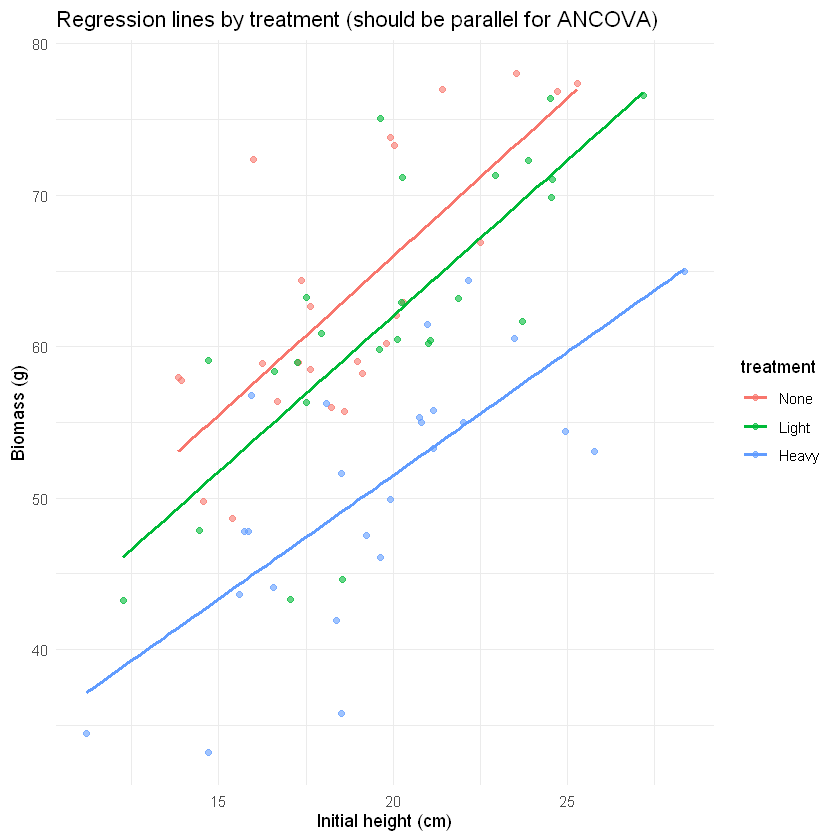

In [2]:
# MUST test this before interpreting adjusted means
# If slopes differ, ANCOVA is not appropriate as typically used
m_full <- lm(biomass ~ treatment * initial_ht, data=grazing)
cat("Interaction model (tests slope homogeneity):\n")
Anova(m_full, type="III")

m_ancova <- lm(biomass ~ treatment + initial_ht, data=grazing)
cat("\nLRT: interaction vs additive model:\n")
print(anova(m_ancova, m_full))
cat("\nNon-significant interaction → slopes homogeneous → ANCOVA valid\n")

# Visualise
ggplot(grazing, aes(initial_ht, biomass, colour=treatment)) +
  geom_point(alpha=0.6) +
  geom_smooth(method="lm", se=FALSE) +
  labs(title="Regression lines by treatment (should be parallel for ANCOVA)",
       x="Initial height (cm)", y="Biomass (g)") +
  theme_minimal()

---
## Step 2: Fit ANCOVA and test adjusted means

In [3]:
# ANCOVA model
cat("ANCOVA — Type III SS:\n")
Anova(m_ancova, type="III")

# Adjusted (least-squares) means at mean covariate value
em <- emmeans(m_ancova, ~ treatment)
cat("\nAdjusted means (at mean initial_ht =", round(mean(grazing$initial_ht),1),"cm):\n")
print(em)
cat("\nPairwise comparisons of adjusted means:\n")
print(pairs(em, adjust="tukey"))

cat("\nNote: unadjusted means vs adjusted means:\n")
tapply(grazing$biomass, grazing$treatment, mean) |> round(2) |> print()
print(data.frame(summary(em)[,c("treatment","emmean")]))
cat("Adjustment changes interpretation when groups differ on covariate.\n")

ANCOVA — Type III SS:


,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1786.647,1,47.79430,1.692310e-09
treatment,2661.727,2,35.60171,1.955983e-11
initial_ht,3265.131,1,87.34500,5.407161e-14
Residuals,2654.122,71,NA,NA



Adjusted means (at mean initial_ht = 19.4 cm):
 treatment emmean   SE df lower.CL upper.CL
 None        64.6 1.23 71     62.2     67.1
 Light       60.9 1.23 71     58.5     63.4
 Heavy       50.5 1.22 71     48.1     53.0

Confidence level used: 0.95 

Pairwise comparisons of adjusted means:
 contrast      estimate   SE df t.ratio p.value
 None - Light      3.69 1.75 71   2.113  0.0944
 None - Heavy     14.10 1.74 71   8.115 <0.0001
 Light - Heavy    10.41 1.73 71   6.012 <0.0001

P value adjustment: tukey method for comparing a family of 3 estimates 

Note: unadjusted means vs adjusted means:
 None Light Heavy 
63.35 61.93 50.80 
  treatment   emmean
1      None 64.62588
2     Light 60.93608
3     Heavy 50.52824
Adjustment changes interpretation when groups differ on covariate.


---
## Visualise ANCOVA: adjusted regression lines

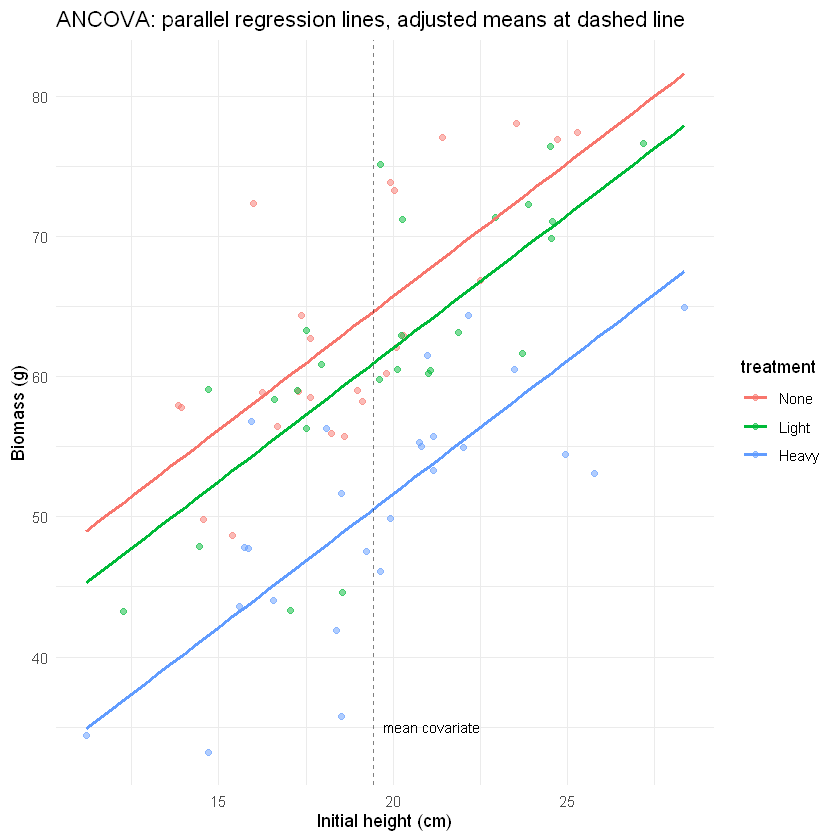

In [4]:
# Plot ANCOVA fit
x_range <- seq(min(grazing$initial_ht), max(grazing$initial_ht), length=50)
preds <- expand.grid(initial_ht=x_range,
                     treatment=c("None","Light","Heavy"))
preds$biomass <- predict(m_ancova, newdata=preds)

ggplot(grazing, aes(initial_ht, biomass, colour=treatment)) +
  geom_point(alpha=0.5) +
  geom_line(data=preds, aes(initial_ht, biomass, colour=treatment), linewidth=1) +
  geom_vline(xintercept=mean(grazing$initial_ht), linetype="dashed", alpha=0.5) +
  annotate("text", x=mean(grazing$initial_ht)+0.3, y=35,
           label="mean covariate", hjust=0, size=3) +
  labs(title="ANCOVA: parallel regression lines, adjusted means at dashed line",
       x="Initial height (cm)", y="Biomass (g)") +
  theme_minimal()

---
## Common Pitfalls

**1. Not testing homogeneity of slopes before interpreting ANCOVA**
If the treatment × covariate interaction is significant, the regression slopes differ across groups. In this case, the treatment effect depends on the covariate value — reporting a single adjusted mean is misleading. Use the Johnson-Neyman technique or report effects at specific covariate values.

**2. Using ANCOVA as a post-hoc fix for non-random group differences**
ANCOVA adjusts for measured covariates, but not for unmeasured confounders. If experimental units were not randomly assigned to treatments, ANCOVA cannot fully remove selection bias. It is most valid in randomised experiments.

**3. Placing the covariate as a response rather than a predictor**
The covariate must be measured before the treatment is applied (or at least be causally unaffected by it). Adjusting for a variable that is itself affected by the treatment can introduce collider bias and distort the treatment estimate.

**4. Reporting only unadjusted means when the covariate effect is large**
If the covariate explains substantial variance, unadjusted means may be misleading. Report both, or report only the adjusted (least-squares) means with clear indication of the adjustment.

**5. Forgetting that emmeans evaluates at the mean covariate value**
By default `emmeans` computes adjusted means at the mean of the covariate. If the covariate range differs substantially across groups, this common value may be outside the range of some groups. Specify `at = list(covariate = value)` for biologically meaningful reference points.

**6. Assuming Type I SS (default in base R `anova()`) is appropriate**
Use Type III SS (`car::Anova(..., type="III")`) for ANCOVA with unbalanced designs or when testing the treatment effect after accounting for the covariate. Type I SS is order-dependent and gives different results depending on which term is listed first.


---
*r_methods_library - Samantha McGarrigle*